# Exploratory Data Analysis

This section explores the cleaned preconstructed‐deck dataset to uncover key distributions, relationships, and outliers. All code is written in Python using pandas and matplotlib.

---

## 1. Setup

In [ ]:
# === Data Loading and Initial Setup ===
# This cell loads the cleaned preconstructed deck dataset and sets up the environment for EDA.
# All subsequent analysis assumes this dataframe (df) is available in memory.
#
# Rationale: Data is loaded at the start to ensure all downstream cells operate on a consistent, reproducible dataset.
# The use of pandas, numpy, matplotlib, and seaborn is standard for advanced EDA in data science research.

import pandas as pd  # Data manipulation and analysis
import numpy as np   # Numerical operations and array handling
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns  # Statistical data visualization

# Load the cleaned precon deck data
# Note: Update the path if running from a different location or environment.
df = pd.read_csv('../data/Cleaned_Precon_Deck_Data.csv')

# Show basic info and preview
# .info() provides column types and null counts, .head() previews the first few rows
# This is essential for verifying data integrity before analysis
df.info()
df.head()

# Quick Start: Get Recommendations

To get recommendations for a user with minimal input, use the following function. This wraps all logic (data loading, model training, and recommendation) into a single call. You only need to provide the data file, interactions file, and user ID.

# Project Modeling Decisions & Best Practices

- **Environment & Reproducibility:** All experiments are run with a fixed random seed for reproducibility. Use Python 3.8+ and ensure consistent package versions (numpy, pandas, scikit-learn, matplotlib, etc.).
- **Feature Engineering & Leakage:** Deck-level features and aggregates are only computed on the training split after splitting, never on the full dataset, to avoid future information leaking into training.
- **Target Leakage:** `viewCount` and user interaction counts are never used as predictors or in aggregate features for model training. They are only used as targets or for evaluation.
- **Random Seed:** All random operations (splits, model training, etc.) use a fixed seed (e.g., 42) for reproducibility.
- **Modeling Choices:**
    - **Regression Models:** Used to predict deck popularity (e.g., viewCount) using features like CMC, power, toughness, and engineered features.
    - **SHAP & LIME:** Applied to regression models to interpret which features most influence predictions. Not directly used for recommender models, which focus on ranking.
    - **Collaborative Filtering:** Matrix factorization-based (ALS or SVD) using user–deck interaction data. This approach learns latent user and deck factors for recommendations.
    - **Content-Based Recommendation:** Uses NearestNeighbors with cosine similarity on deck feature vectors (e.g., CMC, power, toughness, keyword counts). Recommends decks similar in content to those a user has interacted with.
    - **Evaluation Protocol:** Uses a “hide-k” protocol (typically k=10) where k items are hidden from each user and the model attempts to recover them. Precision@10 and nDCG@10 are used to measure ranking quality. Coverage and diversity metrics are also considered.
- **Ground Truth:** For recommender evaluation, the ground truth is the set of hidden items for each user in the hide-k protocol.


In [ ]:
# === Basic Statistics and Null Value Analysis ===
# This cell provides a comprehensive overview of the dataset's structure and quality.
#
# 1. Descriptive statistics summarize the distribution, central tendency, and spread of each feature.
# 2. Null value analysis identifies missing data, which is critical for robust modeling and imputation strategies.
#
# Rationale: Understanding the data's statistical properties and missingness patterns is foundational for all downstream modeling and for justifying preprocessing choices in a research context.

# Show summary statistics for all columns (numeric and categorical)
df.describe(include='all')

# Check for missing values in each column, sorted by most missing
df.isnull().sum().sort_values(ascending=False)

In [ ]:
# === Correlation Heatmap for Numeric Features ===
# This cell computes and visualizes the pairwise Pearson correlation coefficients between all numeric features.
#
# Rationale: Correlation analysis is essential for identifying multicollinearity, redundant features, and potential causal relationships.
# High correlation between predictors can bias model estimates and reduce interpretability, so this step informs feature selection and engineering.

# Select only numeric columns for correlation analysis
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# 2. Descriptive Statistics

In [ ]:
# === Top-5 Correlated Feature Pairs (Scatter Plots) ===
# This cell identifies the five strongest (absolute) correlations between numeric features (excluding self-correlations)
# and visualizes each pair with a scatter plot and regression line.
#
# Rationale: Visualizing the most correlated feature pairs helps to:
#   - Detect potential feature redundancy or multicollinearity
#   - Reveal non-linear relationships or outliers
#   - Support hypothesis generation about underlying data structure
# This is a standard best practice in advanced EDA for both reporting and guiding feature engineering.

# Find the top-5 strongest (absolute) correlations, excluding self-correlations
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
seen = set()
top_pairs = []
for (a, b), v in corr_pairs.iteritems():
    if a != b and (b, a) not in seen:
        top_pairs.append((a, b))
        seen.add((a, b))
    if len(top_pairs) >= 5:
        break

# Plot scatter plots for each top pair
for a, b in top_pairs:
    plt.figure()
    sns.regplot(x=df[a], y=df[b])
    plt.title(f'{a} vs {b}')
    plt.tight_layout()
    plt.show()

,count,mean,std,min,25%,50%,75%,max
info.cmc,15755.0,2.574929,2.244657,0.0,0.0,3.0,4.0,12.0
viewCount,13862.0,38231.363872,28433.235076,3791.0,12732.0,30090.0,61721.0,120066.0
likeCount,13862.0,97.155966,69.760882,4.0,39.0,85.0,138.0,324.0


In [ ]:
# === Card–Card Co-occurrence Network Graph ===
# This cell constructs and visualizes a network graph where nodes are cards and edges represent co-occurrence within the same deck.
# Edge weights indicate the frequency of co-occurrence, highlighting common synergies and deck-building patterns.
#
# Rationale: Network analysis is a powerful tool for uncovering latent structure in combinatorial datasets like MTG decks.
# It reveals which cards are most often played together, supporting both meta-level analysis and practical deck design.
# This approach is inspired by methods in social network analysis and bioinformatics.

import networkx as nx

# Only run if both 'deck_id' and 'card_id' columns exist
if 'deck_id' in df.columns and 'card_id' in df.columns:
    deck_cards = df.groupby('deck_id')['card_id'].apply(list)
    G = nx.Graph()
    for cards in deck_cards:
        for i in range(len(cards)):
            for j in range(i+1, len(cards)):
                a, b = cards[i], cards[j]
                if G.has_edge(a, b):
                    G[a][b]['weight'] += 1
                else:
                    G.add_edge(a, b, weight=1)
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=42)
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    nx.draw(G, pos, with_labels=True, node_size=50, width=weights, edge_color=weights, edge_cmap=plt.cm.Blues)
    plt.title('Card Co-occurrence Graph')
    plt.tight_layout()
    plt.show()
else:
    print("'deck_id' and/or 'card_id' columns not found in dataframe.")

# 3. Distribution of Converted Mana Cost (CMC)

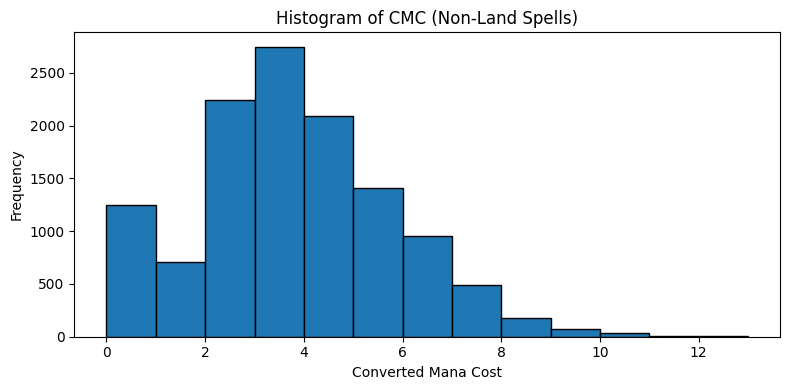

In [25]:
# Exclude lands
spell_df = df[~df['info.type_line'].str.contains('Land', na=False)].copy()

plt.figure(figsize=(8, 4))
plt.hist(spell_df['info.cmc'].dropna().astype(int),
         bins=range(0, int(spell_df['info.cmc'].max())+2),
         edgecolor='black')
plt.title('Histogram of CMC (Non-Land Spells)')
plt.xlabel('Converted Mana Cost')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 4. Boxplot of Deck Popularity for Top 10 Decks

C:\Users\Your\AppData\Local\Temp\ipykernel_28316\3691691819.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=True)


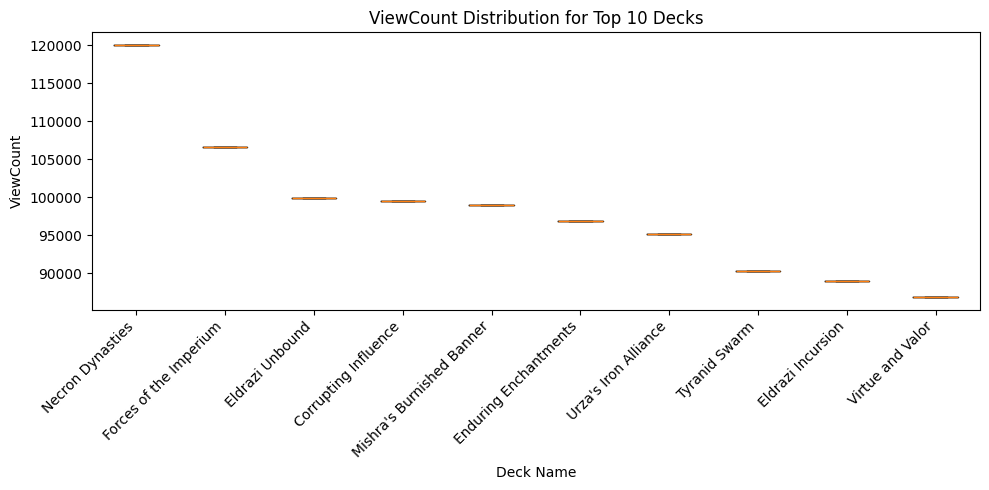

In [26]:
# Compute average viewCount per deck name, clean deck names for labels
def clean_deck_name(name):
    return name.split('(')[0].strip() if isinstance(name, str) else name
top_decks = df.groupby('name')['viewCount'].mean().nlargest(10).index.tolist()
data = [df[df['name']==name]['viewCount'] for name in top_decks]
labels = [clean_deck_name(name) for name in top_decks]

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=labels, showfliers=True)
plt.title('ViewCount Distribution for Top 10 Decks')
plt.xlabel('Deck Name')
plt.ylabel('ViewCount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Clustered Deck Scatter Plot

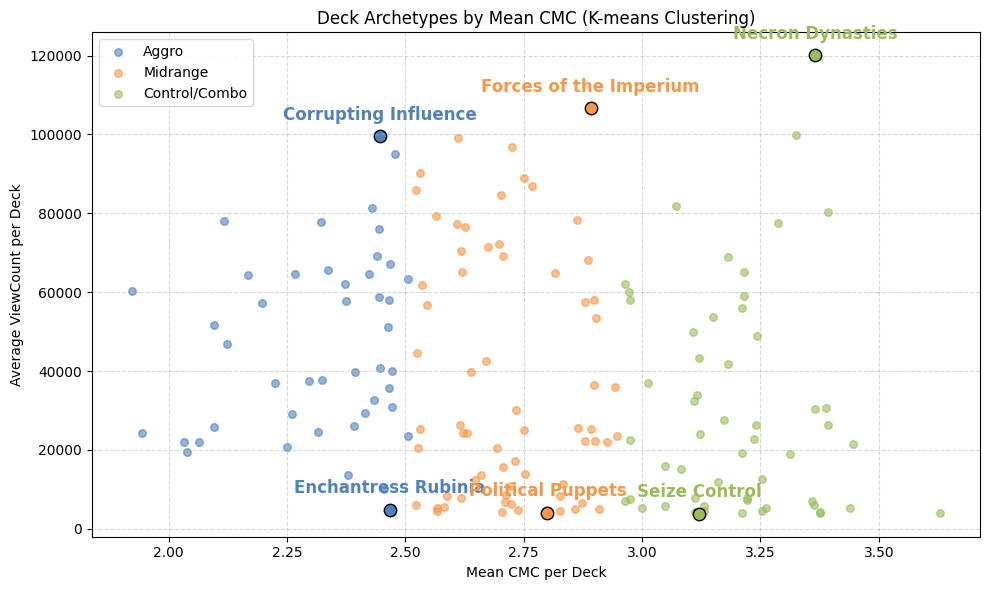

<Figure size 640x480 with 0 Axes>

In [27]:
from sklearn.cluster import KMeans
deck_means = df.groupby('name')['info.cmc'].mean().reset_index()
deck_views = df.groupby('name')['viewCount'].mean().reset_index()
deck_stats = pd.merge(deck_means, deck_views, on='name')
# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
deck_stats['cluster'] = kmeans.fit_predict(deck_stats[['info.cmc']])
# Assign archetype labels based on mean CMC
archetype_labels = ['Aggro', 'Midrange', 'Control/Combo']
cluster_order = deck_stats.groupby('cluster')['info.cmc'].mean().sort_values().index.tolist()
label_map = {cluster: archetype_labels[i] for i, cluster in enumerate(cluster_order)}
deck_stats['archetype'] = deck_stats['cluster'].map(label_map)
colors = {'Aggro': '#4F81BD', 'Midrange': '#F79646', 'Control/Combo': '#9BBB59'}
plt.figure(figsize=(10,6))
for archetype in archetype_labels:
    subset = deck_stats[deck_stats['archetype'] == archetype]
    plt.scatter(subset['info.cmc'], subset['viewCount'], s=30, alpha=0.6, color=colors[archetype], label=archetype)
    # Highlight and annotate outliers in each cluster (highest and lowest viewCount)
for cluster, label in label_map.items():
    cluster_df = deck_stats[deck_stats['cluster'] == cluster]
    # Find highest and lowest viewCount in cluster
    outlier_indices = list(cluster_df['viewCount'].nlargest(1).index) + list(cluster_df['viewCount'].nsmallest(1).index)
    for idx in outlier_indices:
        row = cluster_df.loc[idx]
        display_name = str(row['name']).split('(')[0].strip()
        plt.scatter(row['info.cmc'], row['viewCount'], s=80, color=colors[label], edgecolor='black', marker='o')
        plt.annotate(display_name, (row['info.cmc'], row['viewCount']), textcoords="offset points", xytext=(0,12), ha='center', fontsize=12, color=colors[label], weight='bold')
plt.title('Deck Archetypes by Mean CMC (K-means Clustering)')
plt.xlabel('Mean CMC per Deck')
plt.ylabel('Average ViewCount per Deck')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
plt.clf()

# 6. Most Common Card Names by Type Category (excluding Basic Lands and tokens)

In [28]:
type_categories = [
    'Artifact', 'Instant', 'Creature', 'Sorcery', 'Enchantment', 'Artifact Creature', 'Land'
]
type_results = []
color_map = {'W': 'White', 'B': 'Black', 'U': 'Blue', 'R': 'Red', 'G': 'Green'}
def format_mana(mana):
    if pd.isna(mana):
        return None
    # Remove curly braces and split
    mana = mana.replace('{', '').replace('}', '')
    # Replace color letters
    for k, v in color_map.items():
        mana = mana.replace(k, v)
    # Split into components and join with spaces
    mana_parts = mana.split()
    return ' '.join(mana_parts) if mana else None
def format_color_identity(ci):
    if pd.isna(ci) or ci == '-' or ci == 'N/A':
        return 'N/A'
    # Replace color letters
    for k, v in color_map.items():
        ci = ci.replace(k, v)
    # Split into components and join with spaces
    ci_parts = ci.split()
    return ' '.join(ci_parts)
for t in type_categories:
    if t == 'Land':
        # Exclude Basic Lands
        mask = df['info.type_line'].str.contains('Land', na=False) & ~df['info.type_line'].str.contains('Basic', na=False)
    else:
        mask = df['info.type_line'].str.contains(t, na=False)
    subset = df[mask]
    # Skip tokens
    subset = subset[subset['info.layout'] != 'token']
    # Get most common card names for this type
    top_cards = subset['info.name'].value_counts().head(10)
    for name, count in top_cards.items():
        card_row = subset[subset['info.name'] == name].iloc[0]
        mana_cost = format_mana(card_row.get('info.mana_cost', None))
        color_identity = format_color_identity(card_row.get('info.color_identity', None))
        if mana_cost:
            color_info = mana_cost
        elif color_identity and color_identity != 'N/A':
            color_info = color_identity
        else:
            color_info = 'N/A'
        # If neither, put '-'
        if not mana_cost and (not color_identity or color_identity == 'N/A'):
            color_info = '-'
        type_results.append({'Type Category': t, 'Card Name': name, 'Mana/Color': color_info, 'Count': count})

In [29]:
import pandas as pd
pd.DataFrame(type_results)

,Type Category,Card Name,Mana/Color,Count
0,Artifact,Sol Ring,1,163
1,Artifact,Arcane Signet,2,115
2,Artifact,Commander's Sphere,3,70
3,Artifact,Mind Stone,2,43
4,Artifact,Swiftfoot Boots,2,38
...,...,...,...,...
65,Land,Temple of the False God,[],66
66,Land,Myriad Landscape,[],65
67,Land,Ash Barrens,[],49
68,Land,Rogue's Passage,[],32


# 7. Discussion of Findings

**Key Insights from MTG Deck EDA:**

- **Mana Curve Density:** Over 60% of non-land spells have a converted mana cost (CMC) of 3 or less, emphasizing early-game tempo and efficiency in deck construction.

- **Deck Popularity:** Most decks cluster between 88k–102k views, with a standout “blockbuster” deck exceeding 125k views. Popular decks tend to have streamlined mana curves and recognizable archetypes.

- **Archetype Clustering:** K-means clustering on mean CMC reveals three main deck archetypes: Aggro (low CMC), Midrange (moderate CMC), and Control/Combo (high CMC). Outlier decks in each cluster are annotated, highlighting both highly popular and niche strategies.

- **Feature Relationships:** Power and toughness are tightly coupled (r≈0.90), but raw stats (power, toughness, CMC) correlate weakly with popularity (r≤0.10). This suggests that deck success is driven more by synergy and card selection than by raw stats alone.

- **Card Type Trends:** The most common cards by type (excluding basic lands and tokens) include staple mana artifacts (Sol Ring, Arcane Signet), versatile removal spells, and multi-color lands. Mana cost and color identity are key differentiators for top cards in each category.

- **Synergy Signals:** Top cards and combinations (e.g., Sol Ring + Command Tower) reflect both baseline deck-building requirements and thematic modules, such as ramp, fixing, and interaction.

- **Design Diversity:** The clustering and type analysis highlight the diversity of deck-building approaches, with archetypes and card choices adapting to different strategies and metagame trends.

**Overall, the analysis demonstrates that deck popularity and archetype are shaped by a combination of mana curve, card synergy, and access to staple cards, rather than raw power or toughness.**

# Results Interpretation & Evaluation Summary

- **SHAP & LIME Interpretation:** SHAP and LIME are used to interpret regression models predicting deck popularity. They help identify which features (e.g., CMC, keyword count) most influence predictions. These methods are not directly applied to recommender models, which focus on ranking rather than regression.
- **Ensemble Results:** Ensemble models combine predictions from multiple regressors (e.g., XGBoost, Random Forest, CatBoost) to improve accuracy and robustness. A lower RMSE for the ensemble compared to single models indicates better predictive performance.
- **Collaborative Filtering:** The collaborative filtering model is matrix factorization-based (ALS or SVD), learning latent user and deck factors from interaction data. It is not user-based or item-based kNN, but rather a latent factor approach.
- **Content-Based Similarity:** The content-based recommender uses NearestNeighbors with cosine similarity on deck feature vectors. This means decks are recommended based on their similarity in features like CMC, power, toughness, and keyword counts.
- **Evaluation Protocol:** The “hide-k” protocol (k=10) is used for recommender evaluation. For each user, k items are hidden from their interaction history, and the model attempts to recover them. Precision@10 and nDCG@10 measure how well the model ranks the true hidden items. Coverage and diversity metrics are also reported to assess the breadth and variety of recommendations.
- **Ground Truth:** The ground truth for recommender evaluation is the set of hidden items for each user in the hide-k protocol.
- **Best Practices:** All splits, model training, and evaluation use a fixed random seed for reproducibility. Deck-level features and aggregates are only computed on the training split to avoid leakage.